In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/cleaned_fe.csv")

In [ ]:
X = df.drop(columns=['Time_taken(min)'])
y = np.log1p(df['Time_taken(min)'])

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### mlflo experiment

In [6]:
import os
import dagshub
import mlflow
import os
from dotenv import load_dotenv;load_dotenv()

False

In [9]:
import os
from dotenv import load_dotenv
import mlflow

# Load environment variables from .env file
load_dotenv()

# Set MLflow configuration
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI"))
os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_TRACKING_USERNAME", "")
os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD", "")

# Optional: Verify connection
try:
    mlflow.search_experiments()  # Test connection
    print("MLflow connected successfully!")
except Exception as e:
    print(f"MLflow connection failed: {e}")

MLflow connected successfully!


In [11]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import mlflow
from sklearn.metrics import r2_score

# Start MLflow run for baseline model
mlflow.set_experiment("base model")

with mlflow.start_run():
    # Calculate baseline predictions
    y_train_mean = np.mean(y_train)
    baseline_preds = np.full_like(y_test, y_train_mean)
    
    # Reverse log transformation
    baseline_preds = np.expm1(baseline_preds)
    y_test_actual = np.expm1(y_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_actual, baseline_preds)
    mse = mean_squared_error(y_test_actual, baseline_preds)
    rmse = np.sqrt(mse)  # Calculate RMSE manually
    r2 = r2_score(y_test_actual, baseline_preds)
    
    # Log to MLflow
    mlflow.log_param("model_type", "Baseline_MeanPrediction")
    mlflow.log_param("strategy", "mean_of_y_train")
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)
    
    # Save and log the notebook
    import os
    notebook_path = r"D:\99_acres_ml_project\experiment\experiments.ipynb"
    os.system(f"jupyter nbconvert --to notebook --execute --inplace {notebook_path}")
    mlflow.log_artifact(notebook_path)
    
    print(f"\n Baseline Results:")
    print(f"   MAE: ₹{mae:.2f} Lakhs")
    print(f"   RMSE: ₹{rmse:.2f} Lakhs")
    print(f"   R2 Score: {r2:.3f}")
    print(f"\n Baseline model logged to MLflow")


 Baseline Results:
   MAE: ₹7.48 Lakhs
   RMSE: ₹9.43 Lakhs
   R2 Score: -0.027

 Baseline model logged to MLflow


2026/04/28 14:57:13 INFO mlflow.tracking._tracking_service.client: 🏃 View run judicious-vole-814 at: https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow/#/experiments/0/runs/5305da34028949b598b954aa37f54bd8.
2026/04/28 14:57:13 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow/#/experiments/0.


### random forest as baseline

In [12]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow

# Start MLflow run for Random Forest baseline
mlflow.set_experiment("base model")

with mlflow.start_run():
    # Train Random Forest model
    model = RandomForestRegressor(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Reverse log transformation (if you used log transformation)
    y_pred_actual = np.expm1(y_pred)
    y_test_actual = np.expm1(y_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_actual)
    
    # Log parameters to MLflow
    mlflow.log_param("model_type", "RandomForest_Baseline")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("n_jobs", -1)
    
    # Log metrics to MLflow
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("MSE", mse)
    
    # Log the model
    mlflow.sklearn.log_model(model, "random_forest_baseline_model")
    
    # Optional: Log feature importance
    feature_importance = dict(zip(X_train.columns, model.feature_importances_))
    for feature, importance in sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)[:10]:
        mlflow.log_metric(f"feat_imp_{feature}", importance)
    
    # Save and log the notebook (optional)
    import os
    notebook_path = r"D:\99_acres_ml_project\experiment\experiments.ipynb"
    if os.path.exists(notebook_path):
        os.system(f"jupyter nbconvert --to notebook --execute --inplace {notebook_path}")
        mlflow.log_artifact(notebook_path)
    
    print(f"\n Random Forest Baseline Results:")
    print(f"   MAE: ₹{mae:.2f} Lakhs")
    print(f"   RMSE: ₹{rmse:.2f} Lakhs")
    print(f"   R2 Score: {r2:.3f}")
    print(f"   MSE: {mse:.2f}")
    print(f"\n Model logged to MLflow")

2026/04/28 15:06:44 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.



 Random Forest Baseline Results:
   MAE: ₹3.51 Lakhs
   RMSE: ₹4.45 Lakhs
   R2 Score: 0.771
   MSE: 19.81

 Model logged to MLflow


2026/04/28 15:07:41 INFO mlflow.tracking._tracking_service.client: 🏃 View run abundant-stag-534 at: https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow/#/experiments/0/runs/3071c176c1f54dcdbadebf1d4bbe77e1.
2026/04/28 15:07:41 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow/#/experiments/0.


### Best Algorithm

In [14]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import mlflow
import pandas as pd
import numpy as np

# Expanded algorithms dictionary
algorithms = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'CatBoost': CatBoostRegressor(n_estimators=100, random_state=42, verbose=0),
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR()
}

# Store results
best_r2 = -float('inf')
best_model_name = None
best_mae = None
best_run_id = None

# Start MLflow experiment
mlflow.set_experiment("multiple_algorithm_comparison")

with mlflow.start_run(run_name="All Models Comparison") as parent_run:
    
    results_list = []
    
    for algo_name, model in algorithms.items():
        with mlflow.start_run(run_name=algo_name, nested=True):
            
            print(f"\n{'='*50}")
            print(f"Training: {algo_name}")
            print(f"{'='*50}")
            
            try:
                # Train model
                model.fit(X_train, y_train)
                
                # Predict
                y_pred = model.predict(X_test)
                
                # Calculate metrics
                mae = mean_absolute_error(y_test, y_pred)
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                r2 = r2_score(y_test, y_pred)
                
                # Log parameters
                mlflow.log_param("model_type", algo_name)
                mlflow.log_metric("MAE", mae)
                mlflow.log_metric("RMSE", rmse)
                mlflow.log_metric("R2", r2)
                
                # Log model
                mlflow.sklearn.log_model(model, "model")
                
                # Store results
                results_list.append({
                    'Algorithm': algo_name,
                    'MAE': mae,
                    'RMSE': rmse,
                    'R2': r2,
                    'Run_ID': mlflow.active_run().info.run_id
                })
                
                # Track best model
                if r2 > best_r2:
                    best_r2 = r2
                    best_model_name = algo_name
                    best_mae = mae
                    best_run_id = mlflow.active_run().info.run_id
                
                print(f"   ✅ MAE: ₹{mae:.2f} Lakhs")
                print(f"   ✅ RMSE: ₹{rmse:.2f} Lakhs")
                print(f"   ✅ R2 Score: {r2:.3f}")
                
            except Exception as e:
                print(f"   ❌ Failed: {str(e)[:100]}")
                results_list.append({
                    'Algorithm': algo_name,
                    'MAE': None,
                    'RMSE': None,
                    'R2': None,
                    'Error': str(e)[:100]
                })
    
    # Create and display comparison table
    print("\n" + "="*70)
    print("📊 FINAL MODEL COMPARISON (Sorted by R² Score)")
    print("="*70)
    
    df_results = pd.DataFrame(results_list)
    df_results = df_results.dropna(subset=['R2'])
    df_results = df_results.sort_values('R2', ascending=False)
    
    # Display formatted table
    for idx, row in df_results.iterrows():
        rank_icon = "🏆" if idx == 0 else ("🥈" if idx == 1 else ("🥉" if idx == 2 else "  "))
        print(f"{rank_icon} {row['Algorithm']:20s} | R²: {row['R2']:.4f} | MAE: ₹{row['MAE']:.2f} Lakhs | RMSE: ₹{row['RMSE']:.2f} Lakhs")
    
    print("\n" + "="*70)
    print(f"✅ BEST ALGORITHM FOR YOUR DATA: {best_model_name}")
    print(f"   R² Score: {best_r2:.4f}")
    print(f"   MAE: ₹{best_mae:.2f} Lakhs")
    print(f"   MLflow Run ID: {best_run_id}")
    print("="*70)

2026/04/28 15:47:24 INFO mlflow.tracking.fluent: Experiment with name 'multiple_algorithm_comparison' does not exist. Creating a new experiment.



Training: RandomForest


d:\Swiggy-Delivery-Time-Prediction\venv\lib\site-packages\_distutils_hack\__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
d:\Swiggy-Delivery-Time-Prediction\venv\lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
2026/04/28 15:54:27 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.


   ✅ MAE: ₹0.14 Lakhs
   ✅ RMSE: ₹0.18 Lakhs
   ✅ R2 Score: 0.740


2026/04/28 15:54:27 INFO mlflow.tracking._tracking_service.client: 🏃 View run RandomForest at: https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow/#/experiments/1/runs/82fe3c5dd3214b3fbbbdd5c22763fc4d.
2026/04/28 15:54:27 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow/#/experiments/1.


...

d:\Swiggy-Delivery-Time-Prediction\venv\lib\site-packages\_distutils_hack\__init__.py:18: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
d:\Swiggy-Delivery-Time-Prediction\venv\lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
2026/04/28 15:59:45 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.


   ✅ MAE: ₹0.19 Lakhs
   ✅ RMSE: ₹0.24 Lakhs
   ✅ R2 Score: 0.531


2026/04/28 15:59:45 INFO mlflow.tracking._tracking_service.client: 🏃 View run SVR at: https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow/#/experiments/1/runs/0140aa6a47c343e6a2fc8dd56fd87e2a.
2026/04/28 15:59:45 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow/#/experiments/1.



📊 FINAL MODEL COMPARISON (Sorted by R² Score)
   LightGBM             | R²: 0.7600 | MAE: ₹0.13 Lakhs | RMSE: ₹0.17 Lakhs
   CatBoost             | R²: 0.7521 | MAE: ₹0.14 Lakhs | RMSE: ₹0.17 Lakhs
🥉 XGBoost              | R²: 0.7482 | MAE: ₹0.14 Lakhs | RMSE: ₹0.17 Lakhs
🏆 RandomForest         | R²: 0.7397 | MAE: ₹0.14 Lakhs | RMSE: ₹0.18 Lakhs
🥈 GradientBoosting     | R²: 0.7141 | MAE: ₹0.15 Lakhs | RMSE: ₹0.19 Lakhs
   KNN                  | R²: 0.5790 | MAE: ₹0.17 Lakhs | RMSE: ₹0.23 Lakhs
   SVR                  | R²: 0.5309 | MAE: ₹0.19 Lakhs | RMSE: ₹0.24 Lakhs
   Ridge                | R²: 0.5081 | MAE: ₹0.19 Lakhs | RMSE: ₹0.24 Lakhs
   LinearRegression     | R²: 0.5081 | MAE: ₹0.19 Lakhs | RMSE: ₹0.24 Lakhs
   DecisionTree         | R²: 0.5042 | MAE: ₹0.18 Lakhs | RMSE: ₹0.25 Lakhs
   ElasticNet           | R²: 0.1205 | MAE: ₹0.27 Lakhs | RMSE: ₹0.33 Lakhs
   Lasso                | R²: 0.0563 | MAE: ₹0.28 Lakhs | RMSE: ₹0.34 Lakhs

✅ BEST ALGORITHM FOR YOUR DATA: LightGBM
  

2026/04/28 15:59:46 INFO mlflow.tracking._tracking_service.client: 🏃 View run All Models Comparison at: https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow/#/experiments/1/runs/19b8df10edd04a468151fe4cca52febd.
2026/04/28 15:59:46 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow/#/experiments/1.


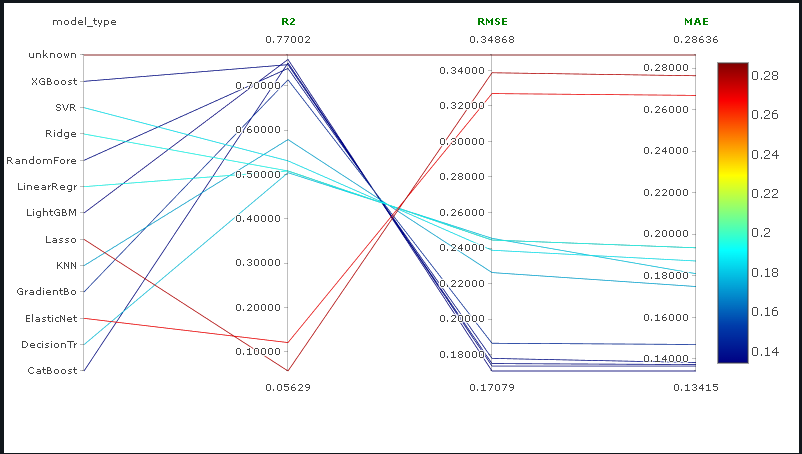

### Hyperparameter Tuning for LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import pandas as pd
import numpy as np

# Set MLflow experiment
mlflow.set_experiment("LightGBM_Hyperparameter_Tuning")

# Define parameter grid for LightGBM
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 10, -1],  # -1 means no limit
    'num_leaves': [31, 50, 100],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Start parent run
with mlflow.start_run(run_name="LightGBM_Hyperparameter_Tuning") as parent_run:
    
    print("🔄 Starting LightGBM Hyperparameter Tuning...")
    print(f"Total combinations: {np.prod([len(v) for v in param_grid.values()])}")
    
    # Perform grid search with cross-validation
    lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    grid_search = GridSearchCV(
        estimator=lgbm,
        param_grid=param_grid,
        cv=5,  # 5-fold cross-validation
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit grid search
    grid_search.fit(X_train, y_train)
    
    # Log each parameter combination as child runs
    print("\n📊 Logging individual model runs to MLflow...")
    for i, (params, mean_score, std_score) in enumerate(zip(
        grid_search.cv_results_['params'],
        grid_search.cv_results_['mean_test_score'],
        grid_search.cv_results_['std_test_score']
    )):
        # Create a readable run name
        run_name = f"LGBM_lr{params['learning_rate']}_nl{params['num_leaves']}_md{params['max_depth']}"
        
        with mlflow.start_run(run_name=run_name, nested=True):
            # Train model with these parameters
            model = lgb.LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1)
            model.fit(X_train, y_train)
            
            # Evaluate on test set
            y_pred = model.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            # Log parameters and metrics
            mlflow.log_params(params)
            mlflow.log_metric("mean_cv_r2", mean_score)
            mlflow.log_metric("std_cv_r2", std_score)
            mlflow.log_metric("test_MAE", mae)
            mlflow.log_metric("test_RMSE", rmse)
            mlflow.log_metric("test_R2", r2)
            
            # Log feature importance for top 10 models (optional)
            if i < 10:  # Only log for first 10 to avoid too many artifacts
                feature_importance = pd.DataFrame({
                    'feature': X_train.columns,
                    'importance': model.feature_importances_
                }).sort_values('importance', ascending=False).head(10)
                
                # Log as artifact
                import tempfile
                with tempfile.TemporaryDirectory() as tmpdir:
                    importance_path = f"{tmpdir}/feature_importance_{run_name}.csv"
                    feature_importance.to_csv(importance_path, index=False)
                    mlflow.log_artifact(importance_path)
    
    # Get best parameters and score
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_
    
    # Log best parameters and score to parent run
    mlflow.log_params(best_params)
    mlflow.log_metric("best_cv_r2_score", best_score)
    
    # Evaluate best model on test set
    best_model = grid_search.best_estimator_
    y_pred_best = best_model.predict(X_test)
    best_mae = mean_absolute_error(y_test, y_pred_best)
    best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
    best_r2 = r2_score(y_test, y_pred_best)
    
    # Log best model test metrics
    mlflow.log_metric("best_test_MAE", best_mae)
    mlflow.log_metric("best_test_RMSE", best_rmse)
    mlflow.log_metric("best_test_R2", best_r2)
    
    # Log feature importance of best model
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Save and log feature importance as artifact
    feature_importance.to_csv('feature_importance_lgbm.csv', index=False)
    mlflow.log_artifact('feature_importance_lgbm.csv')
    
    # Log the best model with input example
    input_example = X_test.iloc[:5]
    mlflow.lightgbm.log_model(
        best_model, 
        "best_lightgbm_model",
        input_example=input_example
    )
    
    # Print results
    print("\n" + "="*70)
    print("🎯 LIGHTGBM HYPERPARAMETER TUNING COMPLETE")
    print("="*70)
    print(f"Best Parameters:")
    for param, value in best_params.items():
        print(f"   {param}: {value}")
    
    print(f"\nBest Cross-Validation R² Score: {best_score:.4f}")
    print(f"\nBest Model Performance on Test Set:")
    print(f"   MAE: ₹{best_mae:.2f} Lakhs (₹{best_mae*100000:.0f})")
    print(f"   RMSE: ₹{best_rmse:.2f} Lakhs")
    print(f"   R² Score: {best_r2:.4f}")
    
    print("\n🔝 TOP 10 FEATURE IMPORTANCE:")
    print(feature_importance.head(10).to_string(index=False))
    
    print("\n📊 MLflow Experiment:")
    print(f"   View at: {mlflow.get_tracking_uri()}")

2026/04/28 16:04:31 INFO mlflow.tracking.fluent: Experiment with name 'LightGBM_Hyperparameter_Tuning' does not exist. Creating a new experiment.


🔄 Starting LightGBM Hyperparameter Tuning...
Total combinations: 2916
Fitting 5 folds for each of 2916 candidates, totalling 14580 fits
